# In search of base-pairing dependency patterns in E. coli non coding regions

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.signal import convolve2d
import math
import argparse
from collections import OrderedDict
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import time
import random

device = "cuda:0"
data_path = 'data'

In [13]:
def get_ci_matrix(filename):

    return np.load(filename)

def plot_ci_matrix(ci_matrix, vmax=None, figsize=[10, 10]):#increase figure size
    plt.rcParams['figure.figsize'] = figsize
    plt.imshow(ci_matrix, cmap="coolwarm", vmax=vmax) if vmax is not None else plt.imshow(ci_matrix, cmap="coolwarm")
    return plt


In [6]:
root_folder = os.path.join(data_path, 'ecoli_dms_processed_data/nc_regions_windows_less_eq_1024')

In [ ]:
all_files = os.listdir(root_folder)
all_files = [os.path.join(root_folder, file) for file in  all_files if ('.npy' in file) and ('_-.npy' not in file)]
all_files

In [18]:
import torch.nn.functional as F



class DependencyMaps(Dataset):
    def __init__(self, all_files):
        self.filenames = all_files

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        file = self.filenames[idx]
        # Add a channel dimension => shape (1, N, N).
        ci_matrix = torch.tensor(get_ci_matrix(file), dtype=torch.float32).unsqueeze(0)
        return ci_matrix

def custom_collate_fn(batch):
    """
    batch: a list of Tensors, each of shape (1, N_i, N_i).
    Because each item is square (height == width), 
    we only need to find one max dimension.
    """

    # 1) Find max dimension (N) in the batch
    max_dim = max(t.shape[-1] for t in batch)  # t.shape is (1, N_i, N_i)

    # 2) Pad each item to (1, max_dim, max_dim)
    padded_batch = []
    for t in batch:
        n = t.shape[-1]  
        pad_size = max_dim - n

        # F.pad(...) expects (left, right, top, bottom)
        # We only need to pad "right" and "bottom" equally
        # because t is already (1, n, n).
        padded_t = F.pad(t, (0, pad_size, 0, pad_size), mode='constant', value=0)
        padded_batch.append(padded_t)

    # 3) Stack them into a single tensor of shape (batch_size, 1, max_dim, max_dim)
    return torch.stack(padded_batch, dim=0)


def custom_collate_fn_fixed_padding(batch):
    """
    batch: a list of Tensors, each of shape (1, N_i, N_i).
    Because each item is square (height == width), 
    we only need to find one max dimension.
    """

    max_dim = 1024 

    padded_batch = []
    for t in batch:
        n = t.shape[-1]  
        pad_size = max_dim - n

        # F.pad(...) expects (left, right, top, bottom)
        # We only need to pad "right" and "bottom" equally
        # because t is already (1, n, n).
        padded_t = F.pad(t, (0, pad_size, 0, pad_size), mode='constant', value=0)
        padded_batch.append(padded_t)

    # 3) Stack them into a single tensor of shape (batch_size, 1, max_dim, max_dim)
    return torch.stack(padded_batch, dim=0)

dataset = DependencyMaps(all_files)
batch_size=128
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn_fixed_padding)

In [10]:
for batch in data_loader:
    print(batch.shape)
    break

torch.Size([128, 1, 1024, 1024])


In [11]:
def create_diagonal_filter(diagonal_width, filter_size, remove_mean=True, antidiagonal=False, negative_filter_value=-1, positive_filter_value=1):

    convolutional_filter = negative_filter_value * np.ones((filter_size, filter_size))

    # set the main antidiagonal and its adjacent diagonals to positive_filter_value
    for offset in range(-math.floor(diagonal_width/2), math.ceil(diagonal_width/2)):
        # adjust the range based on the offset to avoid going out of bounds
        if offset < 0:
            rng = np.arange(-offset, filter_size)
        else:
            rng = np.arange(filter_size - offset)
        
        convolutional_filter[rng, rng+offset] = positive_filter_value

    convolutional_filter = convolutional_filter[:,::-1] if antidiagonal else convolutional_filter # flip the filter with respect to the vertical axis to get an antidiagonal
    if remove_mean:
        convolutional_filter = convolutional_filter - convolutional_filter.mean()

    return convolutional_filter

#create a conv mask that masks the diagonal and the adjacent diagonals
def create_conv_diag_mask(mask_width = 9, filter_size = 5, seq_region_length = 1024):

    conv_mask = torch.zeros((seq_region_length, seq_region_length))

    for k in range(-mask_width // 2 + 1, mask_width // 2 + 1):
        conv_mask += torch.diag(torch.ones(seq_region_length - abs(k)), diagonal=k)

    conv_mask = 1 - conv_mask
    conv_mask =conv_mask.to("cuda")
    return conv_mask


# anti diagonal filter
filter_size = 5
conv_filter = create_diagonal_filter(diagonal_width = 1, filter_size=filter_size, antidiagonal=True, negative_filter_value=-1)
conv_filter = torch.tensor(conv_filter.copy(), dtype=torch.float32).unsqueeze(0).unsqueeze(0).to("cuda")


In [15]:
def anti_diag_conv_batch(batch, conv_filter, conv_mask_width = 3):
    output = F.conv2d(batch, conv_filter, padding='same')
    output = output.squeeze(1)
    
    conv_mask = create_conv_diag_mask(mask_width = conv_mask_width, filter_size = 5, seq_region_length = batch.shape[-1])
    output = output * conv_mask

    return output

In [19]:
conv_batch = anti_diag_conv_batch(batch.to(device), conv_filter)

<module 'matplotlib.pyplot' from '/opt/modules/i12g/anaconda/envs/flash2/lib/python3.8/site-packages/matplotlib/pyplot.py'>

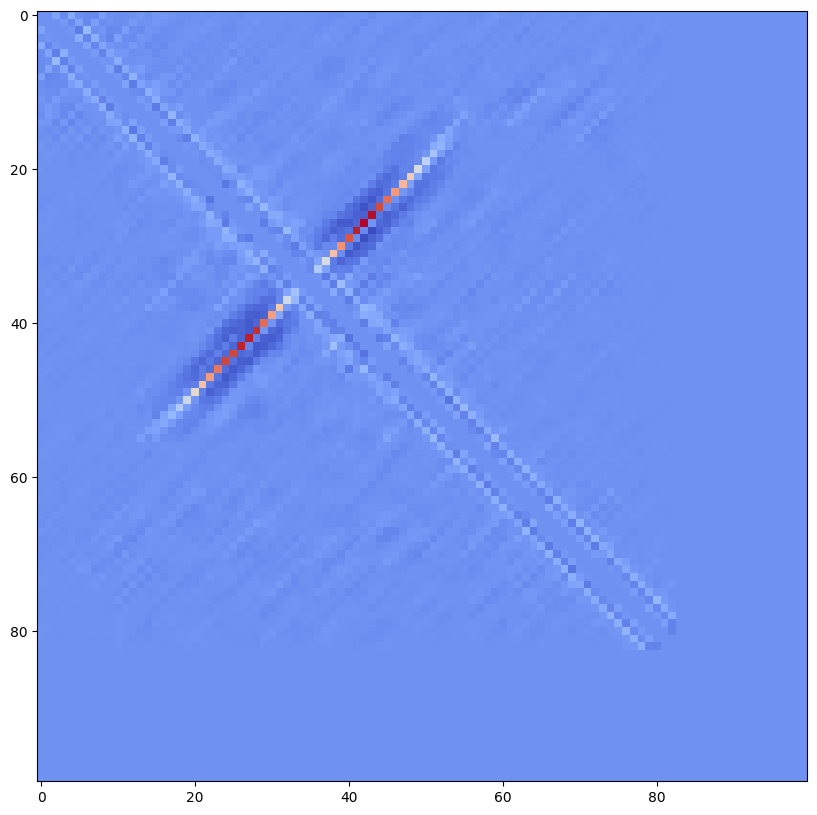

In [182]:
plot_ci_matrix(conv_batch[5].detach().cpu().numpy()[:100,:100])

In [21]:
def filter_anti_diag_positions(batch, conv_filter, conv_threshold=25):
    
    output = anti_diag_conv_batch(batch, conv_filter)
    
    output[output < conv_threshold] = 0
    output[output>0] = 1

    processed_batch = (batch.squeeze() * output)

    return processed_batch

In [22]:
filtered_dep_maps = filter_anti_diag_positions(batch.to(device), conv_filter)

<module 'matplotlib.pyplot' from '/opt/modules/i12g/anaconda/envs/flash2/lib/python3.8/site-packages/matplotlib/pyplot.py'>

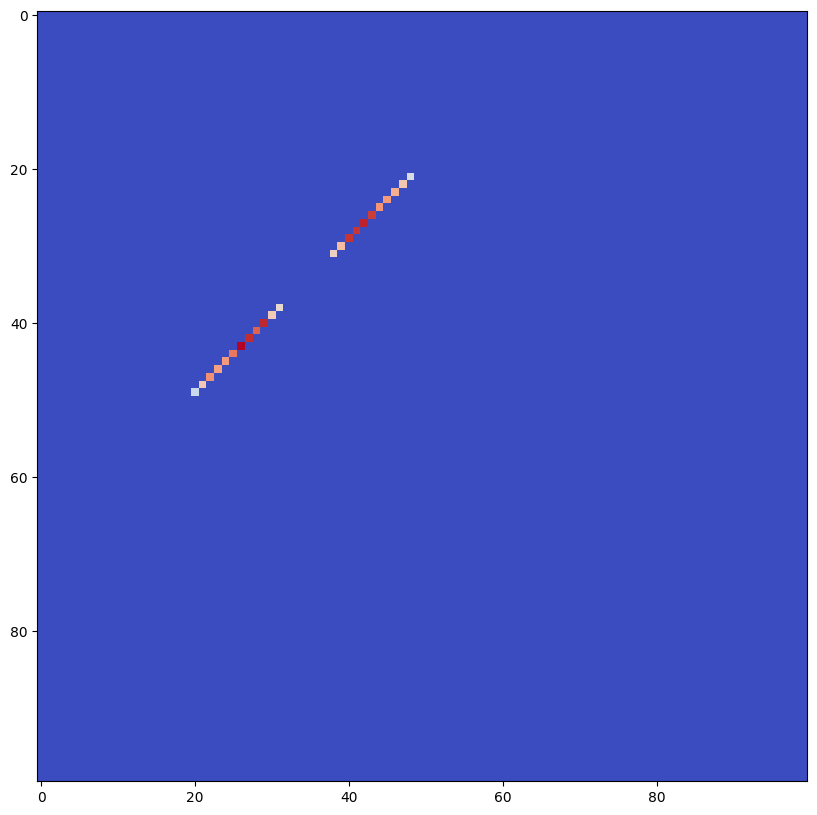

In [185]:
plot_ci_matrix(filtered_dep_maps[5].detach().cpu().numpy()[:100,:100])

In [23]:
from tqdm import tqdm

max_conv_dep_per_query_list = []
max_dep_per_query_list = []


for batch in tqdm(data_loader):

    batch = batch.to(device)
    conv_batch = anti_diag_conv_batch(batch, conv_filter)
    max_conv_dep_per_query_list.append(conv_batch.max(axis=2)[0])

    filtered_dep_maps = filter_anti_diag_positions(batch, conv_filter)
    max_dep_per_query_list.append(filtered_dep_maps.max(axis=2)[0])

max_conv_dep_per_query = torch.cat(max_conv_dep_per_query_list, axis=0)
max_dep_per_query = torch.cat(max_dep_per_query_list, axis=0)

100%|██████████| 26/26 [05:51<00:00, 13.50s/it]


In [17]:
max_conv_dep_per_query.shape

torch.Size([3241, 1024])

In [19]:
def parse_filename(filename, i):
    filename = os.path.basename(filename)
    split_filename = filename.split('_')
    start = int(split_filename[1])
    end = int(split_filename[2])
    strand = split_filename[3].split('.')[0]
    return pd.DataFrame({'Start': start, 'End': end, 'Strand': strand}, index=[i])

In [20]:
#get a dataframe with the start, end and strand of each sequence
file_regions_df = pd.concat([parse_filename(file, i) for i, file in enumerate(dataset.filenames)], axis=0)
file_regions_df

,Start,End,Strand
0,1597562,1598586,+
1,268960,269288,+
2,2221989,2222184,+
3,3403332,3403483,+
4,999191,999215,+
...,...,...,...
3236,416952,417141,+
3237,292948,293219,+
3238,3033010,3033064,+
3239,4189573,4189785,+


In [21]:
all_region_max_conv_dep_per_query = []
all_region_max_dep_per_query = []
all_region_pos_values_0_based = []

for i, row in file_regions_df.iterrows():
    seq_len = row.End - row.Start
    all_region_max_conv_dep_per_query.append(max_conv_dep_per_query[i, :seq_len])
    all_region_max_dep_per_query.append(max_dep_per_query[i, :seq_len])
    all_region_pos_values_0_based.append(torch.arange(row.Start, row.End))

all_region_max_conv_dep_per_query = torch.cat(all_region_max_conv_dep_per_query).cpu()
all_region_max_dep_per_query = torch.cat(all_region_max_dep_per_query).cpu()
all_region_pos_values_0_based = torch.cat(all_region_pos_values_0_based).cpu()
    

In [22]:
region_scores_df = pd.DataFrame({'pos_zero_based': all_region_pos_values_0_based, 'max_conv': all_region_max_conv_dep_per_query, 'max_dep_conv_filtered': all_region_max_dep_per_query})
region_scores_df

,pos_zero_based,max_conv,max_dep_conv_filtered
0,1597562,5.951662,0.0
1,1597563,5.833225,0.0
2,1597564,5.124454,0.0
3,1597565,4.724499,0.0
4,1597566,8.009283,0.0
...,...,...,...
670814,408941,12.401788,0.0
670815,408942,7.899873,0.0
670816,408943,8.805726,0.0
670817,408944,8.637608,0.0


In [23]:
region_scores_df.sort_values('pos_zero_based', inplace=True)
region_scores_df

,pos_zero_based,max_conv,max_dep_conv_filtered
586884,0,5.035628,0.0
586885,1,5.345491,0.0
586886,2,5.916111,0.0
586887,3,4.534877,0.0
586888,4,5.569168,0.0
...,...,...,...
169184,4641647,6.082168,0.0
169185,4641648,6.007463,0.0
169186,4641649,6.144525,0.0
169187,4641650,6.938490,0.0


In [24]:
region_scores_df['pos_1_based'] = region_scores_df['pos_zero_based'] + 1
region_scores_df

,pos_zero_based,max_conv,max_dep_conv_filtered,pos_1_based
586884,0,5.035628,0.0,1
586885,1,5.345491,0.0,2
586886,2,5.916111,0.0,3
586887,3,4.534877,0.0,4
586888,4,5.569168,0.0,5
...,...,...,...,...
169184,4641647,6.082168,0.0,4641648
169185,4641648,6.007463,0.0,4641649
169186,4641649,6.144525,0.0,4641650
169187,4641650,6.938490,0.0,4641651


In [31]:
region_scores_df = region_scores_df.reset_index(drop=True)
region_scores_send_incarnato_df = region_scores_df.copy()
region_scores_send_incarnato_df.drop('pos_zero_based', axis=1, inplace=True)
region_scores_send_incarnato_df.rename({'pos_1_based':'genome_pos'}, axis=1, inplace=True)
region_scores_send_incarnato_df.sort_values('max_conv', ascending=False, inplace=True)
region_scores_send_incarnato_df = region_scores_send_incarnato_df.loc[:, ['genome_pos', 'max_conv', 'max_dep_conv_filtered']].copy()
region_scores_send_incarnato_df.to_csv(os.path.join(data_path, 'ecoli_dms_processed_data/ecoli_noncoding_regions_anti_diag_scores.tsv'), index=False, sep='\t')

## Get pairs of intervals for each antidiagonal

In [ ]:
idxs = filtered_dep_maps.max(axis=2)[1]

<module 'matplotlib.pyplot' from '/opt/modules/i12g/anaconda/envs/flash2/lib/python3.8/site-packages/matplotlib/pyplot.py'>

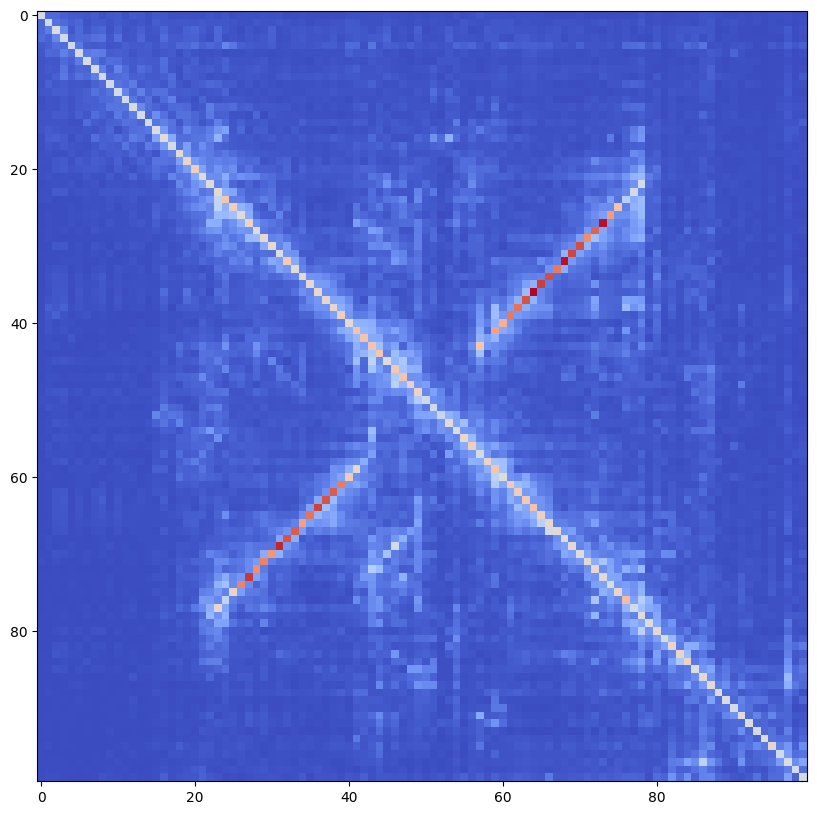

In [ ]:
plot_ci_matrix(batch[3, 0].cpu().numpy()[:100,:100])

In [ ]:
filtered_dep_maps[3].shape

torch.Size([1024, 1024])

In [ ]:
conv_batch.max(axis=2)[0][3].max()

tensor(58.2887, device='cuda:0')

In [ ]:
list(filtered_dep_maps.max(axis=2)[1][3])


[tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(0, device='cuda:0'),
 tensor(76, device='cuda:0'),
 tensor(75, device='cuda:0'),
 tensor(74, device='cuda:0'),
 tensor(73, device='cuda:0'),
 tensor(72, device='cuda:0'),
 tensor(71, device='cuda:0'),
 tensor(70, device='cuda:0'),
 tensor(69, device='cuda:0'),
 tensor(68, device='cuda:0'),
 tensor(67, device='cuda:0'),
 ten

<module 'matplotlib.pyplot' from '/opt/modules/i12g/anaconda/envs/flash2/lib/python3.8/site-packages/matplotlib/pyplot.py'>

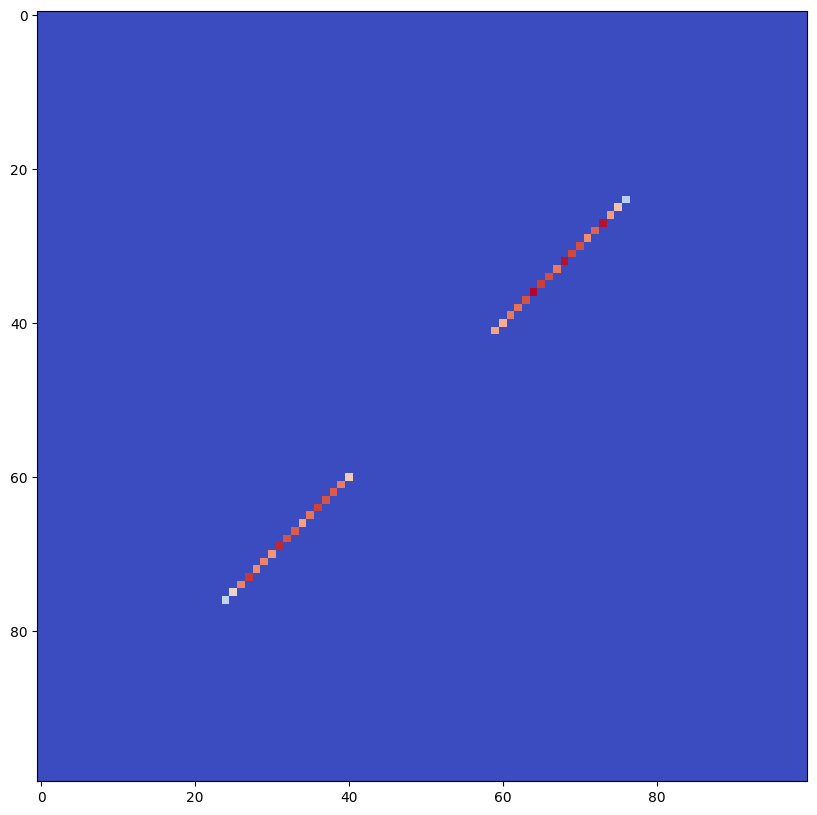

In [ ]:
plot_ci_matrix(filtered_dep_maps[3].cpu().numpy()[:100,:100])

<module 'matplotlib.pyplot' from '/opt/modules/i12g/anaconda/envs/flash2/lib/python3.8/site-packages/matplotlib/pyplot.py'>

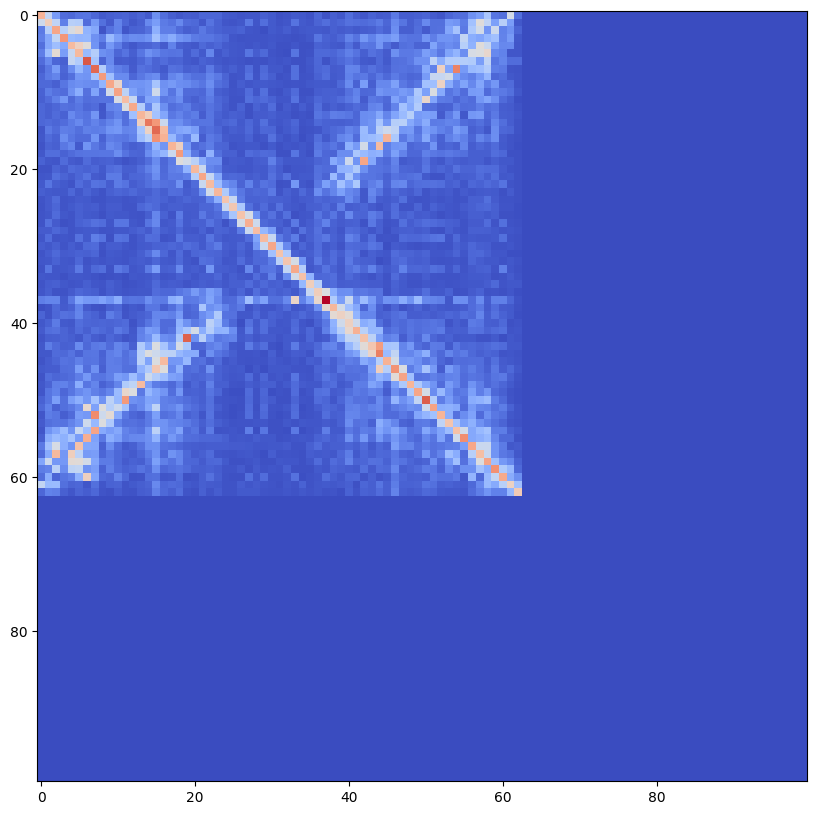

In [ ]:
plot_ci_matrix(batch[5, 0].cpu().numpy()[:100,:100])

In [ ]:
max_j = filtered_dep_maps.max(axis=2)[1][3]

In [ ]:
idxs = conv_batch.max(axis=2)[1]

In [ ]:
list(idxs[0])

[tensor(4, device='cuda:0'),
 tensor(5, device='cuda:0'),
 tensor(6, device='cuda:0'),
 tensor(7, device='cuda:0'),
 tensor(8, device='cuda:0'),
 tensor(1, device='cuda:0'),
 tensor(2, device='cuda:0'),
 tensor(3, device='cuda:0'),
 tensor(4, device='cuda:0'),
 tensor(13, device='cuda:0'),
 tensor(6, device='cuda:0'),
 tensor(15, device='cuda:0'),
 tensor(16, device='cuda:0'),
 tensor(9, device='cuda:0'),
 tensor(10, device='cuda:0'),
 tensor(19, device='cuda:0'),
 tensor(12, device='cuda:0'),
 tensor(21, device='cuda:0'),
 tensor(22, device='cuda:0'),
 tensor(23, device='cuda:0'),
 tensor(24, device='cuda:0'),
 tensor(17, device='cuda:0'),
 tensor(26, device='cuda:0'),
 tensor(19, device='cuda:0'),
 tensor(28, device='cuda:0'),
 tensor(29, device='cuda:0'),
 tensor(22, device='cuda:0'),
 tensor(31, device='cuda:0'),
 tensor(24, device='cuda:0'),
 tensor(33, device='cuda:0'),
 tensor(34, device='cuda:0'),
 tensor(27, device='cuda:0'),
 tensor(36, device='cuda:0'),
 tensor(37, device='c

In [95]:
from tqdm import tqdm

#max_conv_dep_per_query_list = []
max_dep_idx_per_query_list = []
max_dep_per_query_list = []


for batch in tqdm(data_loader):

    batch = batch.to(device)
    #conv_batch = anti_diag_conv_batch(batch, conv_filter)
    #max_conv_dep_per_query_list.append(conv_batch.max(axis=2)[0])

    filtered_dep_maps = filter_anti_diag_positions(batch, conv_filter)
    max_dep_idx_per_query_list.append(filtered_dep_maps.max(axis=2)[1])
    max_dep_per_query_list.append(filtered_dep_maps.max(axis=2)[0])

#max_conv_dep_per_query = torch.cat(max_conv_dep_per_query_list, axis=0)
max_dep_idx_per_query = torch.cat(max_dep_idx_per_query_list, axis=0)
max_dep_per_query = torch.cat(max_dep_per_query_list, axis=0)

100%|██████████| 26/26 [03:19<00:00,  7.69s/it]


In [96]:
max_dep_idx_per_query.shape

torch.Size([3241, 1024])

In [99]:
#get a dataframe with the start, end and strand of each sequence
file_regions_df = pd.concat([parse_filename(file, i) for i, file in enumerate(dataset.filenames)], axis=0)
file_regions_df

,Start,End,Strand
0,1597562,1598586,+
1,268960,269288,+
2,2221989,2222184,+
3,3403332,3403483,+
4,999191,999215,+
...,...,...,...
3236,416952,417141,+
3237,292948,293219,+
3238,3033010,3033064,+
3239,4189573,4189785,+


In [181]:
#all_region_max_conv_dep_per_query = []
all_region_max_idx_dep_per_query = []
all_region_max_dep_per_query = []
all_region_pos_values_0_based = []

for i, row in file_regions_df.iterrows():
    seq_len = row.End - row.Start
    #all_region_max_conv_dep_per_query.append(max_conv_dep_per_query[i, :seq_len])
    all_region_max_idx_dep_per_query.append(max_dep_idx_per_query[i, :seq_len] + row.Start)
    all_region_max_dep_per_query.append(max_dep_per_query[i, :seq_len])
    all_region_pos_values_0_based.append(torch.arange(row.Start, row.End))

#all_region_max_conv_dep_per_query = torch.cat(all_region_max_conv_dep_per_query).cpu()
all_region_max_idx_dep_per_query = torch.cat(all_region_max_idx_dep_per_query).cpu()
all_region_max_dep_per_query = torch.cat(all_region_max_dep_per_query).cpu()
all_region_pos_values_0_based = torch.cat(all_region_pos_values_0_based).cpu()
    

In [182]:
region_scores_df = pd.DataFrame({'pos_zero_based': all_region_pos_values_0_based, 'max_dep_idx_conv_filtered': all_region_max_idx_dep_per_query, 'max_dep_conv_filtered': all_region_max_dep_per_query})
region_scores_df

,pos_zero_based,max_dep_idx_conv_filtered,max_dep_conv_filtered
0,1597562,1597562,0.0
1,1597563,1597562,0.0
2,1597564,1597562,0.0
3,1597565,1597562,0.0
4,1597566,1597562,0.0
...,...,...,...
670814,408941,408461,0.0
670815,408942,408461,0.0
670816,408943,408461,0.0
670817,408944,408461,0.0


In [183]:
region_scores_df = region_scores_df[region_scores_df['max_dep_conv_filtered'] > 0].copy() ##consider only the regions with a positive score (antidiag filter >25)
region_scores_df

,pos_zero_based,max_dep_idx_conv_filtered,max_dep_conv_filtered
1980,1886811,1886859,7.243387
1981,1886812,1886858,5.522190
1982,1886813,1886857,10.572660
1983,1886814,1886856,7.056920
1984,1886815,1886855,9.041441
...,...,...,...
670159,4189610,4189601,7.402950
670160,4189611,4189600,8.129076
670161,4189612,4189599,7.226960
670162,4189613,4189598,5.638065


In [184]:
ij_incarnato_df = region_scores_df.copy()
ij_incarnato_df.rename({'pos_zero_based':'i_pos', 'max_dep_idx_conv_filtered':'j_pos', 'max_dep_conv_filtered':'score'}, axis=1, inplace=True)
ij_incarnato_df['i_pos'] = ij_incarnato_df['i_pos'] + 1 #1based
ij_incarnato_df['j_pos'] = ij_incarnato_df['j_pos'] + 1
ij_incarnato_df

,i_pos,j_pos,score
1980,1886812,1886860,7.243387
1981,1886813,1886859,5.522190
1982,1886814,1886858,10.572660
1983,1886815,1886857,7.056920
1984,1886816,1886856,9.041441
...,...,...,...
670159,4189611,4189602,7.402950
670160,4189612,4189601,8.129076
670161,4189613,4189600,7.226960
670162,4189614,4189599,5.638065


In [185]:
ij_incarnato_df.reset_index(drop=True, inplace=True)
ij_incarnato_df.to_csv(os.path.join(data_path, 'ecoli_noncoding_regions_anti_diag_ij_scores.tsv'), index=False, sep='\t')

In [121]:
region_scores_j_pr = region_scores_df.copy()
region_scores_j_pr['Start'] = region_scores_j_pr['max_dep_idx_conv_filtered']
region_scores_j_pr['End'] = region_scores_j_pr['Start'] + 1
region_scores_j_pr['Strand'] = '+'

In [122]:
region_scores_j_pr

,pos_zero_based,max_dep_idx_conv_filtered,max_dep_conv_filtered,Start,End,Strand
1980,1886811,1886859,7.243387,1886859,1886860,+
1981,1886812,1886858,5.522190,1886858,1886859,+
1982,1886813,1886857,10.572660,1886857,1886858,+
1983,1886814,1886856,7.056920,1886856,1886857,+
1984,1886815,1886855,9.041441,1886855,1886856,+
...,...,...,...,...,...,...
670159,4189610,4189601,7.402950,4189601,4189602,+
670160,4189611,4189600,8.129076,4189600,4189601,+
670161,4189612,4189599,7.226960,4189599,4189600,+
670162,4189613,4189598,5.638065,4189598,4189599,+


In [123]:
import pyranges as pr
#region_scores_pr.drop(['pos_zero_based', 'max_dep_idx_conv_filtered', 'max_dep_conv_filtered'], axis=1, inplace=True)
region_scores_j_pr['Chromosome'] = 'Chromosome'
region_scores_j_pr = pr.PyRanges(region_scores_j_pr)
region_scores_j_pr

,pos_zero_based,max_dep_idx_conv_filtered,max_dep_conv_filtered,Start,End,Strand,Chromosome
0,1886811,1886859,7.243387,1886859,1886860,+,Chromosome
1,1886812,1886858,5.522190,1886858,1886859,+,Chromosome
2,1886813,1886857,10.572660,1886857,1886858,+,Chromosome
3,1886814,1886856,7.056920,1886856,1886857,+,Chromosome
4,1886815,1886855,9.041441,1886855,1886856,+,Chromosome
...,...,...,...,...,...,...,...
15455,4189610,4189601,7.402950,4189601,4189602,+,Chromosome
15456,4189611,4189600,8.129076,4189600,4189601,+,Chromosome
15457,4189612,4189599,7.226960,4189599,4189600,+,Chromosome
15458,4189613,4189598,5.638065,4189598,4189599,+,Chromosome


In [124]:
region_scores_j_df = region_scores_j_pr.cluster().df
region_scores_j_df

,pos_zero_based,max_dep_idx_conv_filtered,max_dep_conv_filtered,Start,End,Strand,Chromosome,Cluster
0,304,275,4.642959,275,276,+,Chromosome,1
1,303,276,6.469240,276,277,+,Chromosome,1
2,302,277,8.206045,277,278,+,Chromosome,1
3,301,278,7.776872,278,279,+,Chromosome,1
4,300,279,7.892864,279,280,+,Chromosome,1
...,...,...,...,...,...,...,...,...
15455,4639546,4639563,8.318296,4639563,4639564,+,Chromosome,2602
15456,4639545,4639564,7.781038,4639564,4639565,+,Chromosome,2602
15457,4639544,4639565,5.443701,4639565,4639566,+,Chromosome,2602
15458,4639543,4639566,6.438587,4639566,4639567,+,Chromosome,2602


In [125]:
region_scores_j_df.rename({'Cluster':'Cluster_j'}, axis=1, inplace=True)
region_scores_j_df.drop(['Start', 'End'], axis=1, inplace=True)

In [126]:
region_scores_i_pr = region_scores_j_df.copy()
region_scores_i_pr['Start'] = region_scores_i_pr['pos_zero_based']
region_scores_i_pr['End'] = region_scores_i_pr['Start'] + 1
region_scores_i_pr = pr.PyRanges(region_scores_i_pr)
region_scores_i_pr

,pos_zero_based,max_dep_idx_conv_filtered,max_dep_conv_filtered,Strand,Chromosome,Cluster_j,Start,End
0,304,275,4.642959,+,Chromosome,1,304,305
1,303,276,6.469240,+,Chromosome,1,303,304
2,302,277,8.206045,+,Chromosome,1,302,303
3,301,278,7.776872,+,Chromosome,1,301,302
4,300,279,7.892864,+,Chromosome,1,300,301
...,...,...,...,...,...,...,...,...
15455,4639546,4639563,8.318296,+,Chromosome,2602,4639546,4639547
15456,4639545,4639564,7.781038,+,Chromosome,2602,4639545,4639546
15457,4639544,4639565,5.443701,+,Chromosome,2602,4639544,4639545
15458,4639543,4639566,6.438587,+,Chromosome,2602,4639543,4639544


In [128]:
region_scores_i_df = region_scores_i_pr.cluster().df
region_scores_i_df.rename({'Cluster':'Cluster_i'}, axis=1, inplace=True)
region_scores_i_df

,pos_zero_based,max_dep_idx_conv_filtered,max_dep_conv_filtered,Strand,Chromosome,Cluster_j,Start,End,Cluster_i
0,276,303,5.030137,+,Chromosome,2,276,277,1
1,277,302,6.552937,+,Chromosome,2,277,278,1
2,278,301,7.367975,+,Chromosome,2,278,279,1
3,279,300,7.937395,+,Chromosome,2,279,280,1
4,280,299,8.008023,+,Chromosome,2,280,281,1
...,...,...,...,...,...,...,...,...,...
15455,4639564,4639545,8.733958,+,Chromosome,2601,4639564,4639565,2551
15456,4639565,4639544,8.781151,+,Chromosome,2601,4639565,4639566,2551
15457,4639566,4639543,7.803535,+,Chromosome,2601,4639566,4639567,2551
15458,4639567,4639542,7.100577,+,Chromosome,2601,4639567,4639568,2551


In [130]:
region_scores_i_df.groupby('Cluster_i')['Cluster_j'].apply(lambda x: len(x.unique())).value_counts()

Cluster_j
1    2352
2     187
3       9
5       2
4       1
Name: count, dtype: int64

In [139]:
(region_scores_i_df.groupby('Cluster_i')['Cluster_j'].apply(lambda x: len(x.unique()))>1).idxmax()

89

In [141]:
cluster_i_df = region_scores_i_df[region_scores_i_df['Cluster_i'] ==89].copy()
cluster_i_df

,pos_zero_based,max_dep_idx_conv_filtered,max_dep_conv_filtered,Strand,Chromosome,Cluster_j,Start,End,Cluster_i
458,225440,225434,0.550869,+,Chromosome,88,225440,225441,89
459,225441,225433,8.605548,+,Chromosome,88,225441,225442,89
460,225442,225432,14.532525,+,Chromosome,88,225442,225443,89
461,225443,225431,12.746401,+,Chromosome,88,225443,225444,89
462,225444,225430,14.337932,+,Chromosome,88,225444,225445,89
463,225445,225429,8.575089,+,Chromosome,88,225445,225446,89
464,225446,225386,11.381742,+,Chromosome,85,225446,225447,89
465,225447,225385,8.409496,+,Chromosome,85,225447,225448,89
466,225448,225384,9.820104,+,Chromosome,85,225448,225449,89
467,225449,225383,12.361917,+,Chromosome,85,225449,225450,89


In [148]:
unique_cluster_j_cluster_i_bounds = cluster_i_df.groupby('Cluster_j')['pos_zero_based'].apply(lambda x: [x.min(), x.max()]).to_frame()
unique_cluster_j_cluster_j_bounds = cluster_i_df.groupby('Cluster_j')['max_dep_idx_conv_filtered'].apply(lambda x: [x.min(), x.max()]).to_frame()
unique_cluster_j_cluster_i_bounds, unique_cluster_j_cluster_j_bounds

(             pos_zero_based
 Cluster_j                  
 85         [225446, 225453]
 88         [225440, 225445],
           max_dep_idx_conv_filtered
 Cluster_j                          
 85                 [225379, 225386]
 88                 [225429, 225434])

In [149]:
unique_cluster_j_cluster_i_bounds.merge(unique_cluster_j_cluster_j_bounds, left_index=True, right_index=True)

,pos_zero_based,max_dep_idx_conv_filtered
Cluster_j,,
85,"[225446, 225453]","[225379, 225386]"
88,"[225440, 225445]","[225429, 225434]"


In [153]:
def get_cluster_pair_intervals(cluster_i_df):
    unique_cluster_j_cluster_i_bounds = cluster_i_df.groupby('Cluster_j')['pos_zero_based'].apply(lambda x: [x.min(), x.max()+1]).to_frame() # add 1 to the max to include the last position
    unique_cluster_j_cluster_j_bounds = cluster_i_df.groupby('Cluster_j')['max_dep_idx_conv_filtered'].apply(lambda x: [x.min(), x.max()+1]).to_frame() # add 1 to the max to include the last position
    unique_anti_diag_adjacent_intervals_df = unique_cluster_j_cluster_i_bounds.merge(unique_cluster_j_cluster_j_bounds, left_index=True, right_index=True)
    
    return unique_anti_diag_adjacent_intervals_df

In [154]:
# get all cluster pair intervals
all_cluster_pair_intervals = region_scores_i_df.groupby('Cluster_i').apply(get_cluster_pair_intervals)
all_cluster_pair_intervals

,,pos_zero_based,max_dep_idx_conv_filtered
Cluster_i,Cluster_j,,
1,2,"[276, 287]","[293, 304]"
2,1,"[293, 305]","[275, 287]"
3,4,"[5539, 5542]","[5554, 5557]"
4,3,"[5555, 5557]","[5539, 5541]"
5,5,"[14135, 14136]","[14111, 14112]"
...,...,...,...
2547,2598,"[4628751, 4628753]","[4628764, 4628766]"
2548,2599,"[4628810, 4628821]","[4628768, 4628779]"
2549,2600,"[4628837, 4628842]","[4628816, 4628821]"


In [155]:
all_cluster_pair_intervals.rename({'pos_zero_based':'Cluster_i_bounds', 'max_dep_idx_conv_filtered':'Cluster_j_bounds'}, axis=1, inplace=True)
all_cluster_pair_intervals

,,Cluster_i_bounds,Cluster_j_bounds
Cluster_i,Cluster_j,,
1,2,"[276, 287]","[293, 304]"
2,1,"[293, 305]","[275, 287]"
3,4,"[5539, 5542]","[5554, 5557]"
4,3,"[5555, 5557]","[5539, 5541]"
5,5,"[14135, 14136]","[14111, 14112]"
...,...,...,...
2547,2598,"[4628751, 4628753]","[4628764, 4628766]"
2548,2599,"[4628810, 4628821]","[4628768, 4628779]"
2549,2600,"[4628837, 4628842]","[4628816, 4628821]"


In [165]:
def process_row_to_2_intervals(row):
    cluster_i_bounds = row['Cluster_i_bounds']
    cluster_j_bounds = row['Cluster_j_bounds']
    return pd.DataFrame({'Start_i': cluster_i_bounds[0], 'End_i': cluster_i_bounds[1], 'Start_j': cluster_j_bounds[0], 'End_j': cluster_j_bounds[1]}, index = [0])

In [174]:
processed_cluster_pair_intervals_df = pd.concat(list(all_cluster_pair_intervals.apply(process_row_to_2_intervals, axis=1)), axis=0).reset_index(drop=True)
processed_cluster_pair_intervals_df

,Start_i,End_i,Start_j,End_j
0,276,287,293,304
1,293,305,275,287
2,5539,5542,5554,5557
3,5555,5557,5539,5541
4,14135,14136,14111,14112
...,...,...,...,...
2762,4628751,4628753,4628764,4628766
2763,4628810,4628821,4628768,4628779
2764,4628837,4628842,4628816,4628821
2765,4639542,4639553,4639557,4639568


In [175]:
processed_cluster_pair_intervals_df['Start_i'] = processed_cluster_pair_intervals_df['Start_i'] + 1 # convert to 1-based and closed end interval
processed_cluster_pair_intervals_df['Start_j'] = processed_cluster_pair_intervals_df['Start_j'] + 1 # convert to 1-based and closed end interval

In [177]:
processed_cluster_pair_intervals_df = processed_cluster_pair_intervals_df.reset_index(names='anti_diagonal_id')
processed_cluster_pair_intervals_df

,anti_diagonal_id,Start_i,End_i,Start_j,End_j
0,0,277,287,294,304
1,1,294,305,276,287
2,2,5540,5542,5555,5557
3,3,5556,5557,5540,5541
4,4,14136,14136,14112,14112
...,...,...,...,...,...
2762,2762,4628752,4628753,4628765,4628766
2763,2763,4628811,4628821,4628769,4628779
2764,2764,4628838,4628842,4628817,4628821
2765,2765,4639543,4639553,4639558,4639568


In [178]:
processed_cluster_pair_intervals_df.to_csv(os.path.join(data_path, 'ecoli_dms_processed_data/ecoli_noncoding_regions_filtered_anti_diag_coords.tsv'), index=False, sep='\t')